In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

In [51]:
df = pd.read_csv("/content/stroke_data_sprint1_final.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# 1. Statistical Analysis

Numerical Columns

In [52]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


Measures of Central Tendency

In [53]:
central_tendency = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0]
})

central_tendency

,Mean,Median,Mode
id,36517.829354,36932.000,67.00
age,43.226614,45.000,78.00
hypertension,0.097456,0.000,0.00
heart_disease,0.054012,0.000,0.00
avg_glucose_level,106.147677,91.885,93.88
bmi,28.862035,28.100,28.10
stroke,0.048728,0.000,0.00


Observation  :


 - The mean, median and mode were calculated for all numerical variables.

 - The average age is around 43 years, while the median age is 45 years.

 - The average BMI is around 28.86, with a median of approximately 28.10.

 - Average glucose level has a higher mean than median, showing that some patients have comparatively high glucose values.

 - The binary health variables have lower means because most patients belong to the 0 category.

Measures of Dispersion

In [54]:
dispersion = pd.DataFrame({
    "Minimum": df[numerical_columns].min(),
    "Maximum": df[numerical_columns].max(),
    "Range": df[numerical_columns].max() - df[numerical_columns].min(),
    "Variance": df[numerical_columns].var(),
    "Standard Deviation": df[numerical_columns].std()
})

dispersion

,Minimum,Maximum,Range,Variance,Standard Deviation
id,67.00,72940.00,72873.00,4.478185e+08,21161.721625
age,0.08,82.00,81.92,5.113318e+02,22.612647
hypertension,0.00,1.00,1.00,8.797552e-02,0.296607
heart_disease,0.00,1.00,1.00,5.110447e-02,0.226063
avg_glucose_level,55.12,271.74,216.62,2.050601e+03,45.283560
bmi,10.30,97.60,87.30,5.928326e+01,7.699562
stroke,0.00,1.00,1.00,4.636264e-02,0.215320


Observation  :

 - Age has a wide range because the dataset contains both younger and older patients.

 - Average glucose level also has considerable variation.

 - BMI shows variation between patients, including some higher values.

 - Standard deviation helps show how much the observations vary around their respective means.

Distribution Analysis

Age

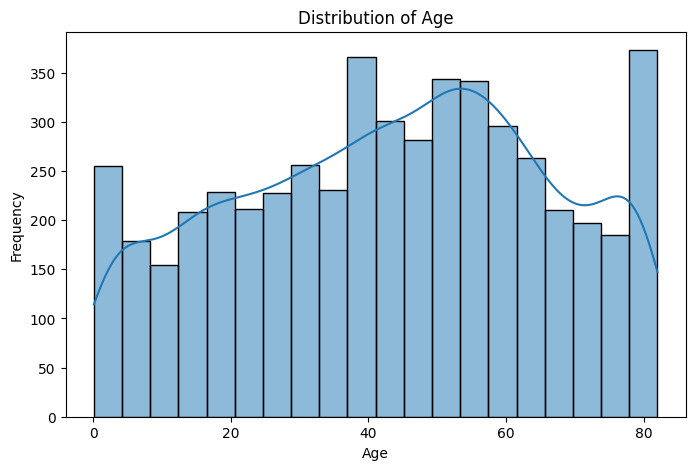

In [55]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Average Glucose Level

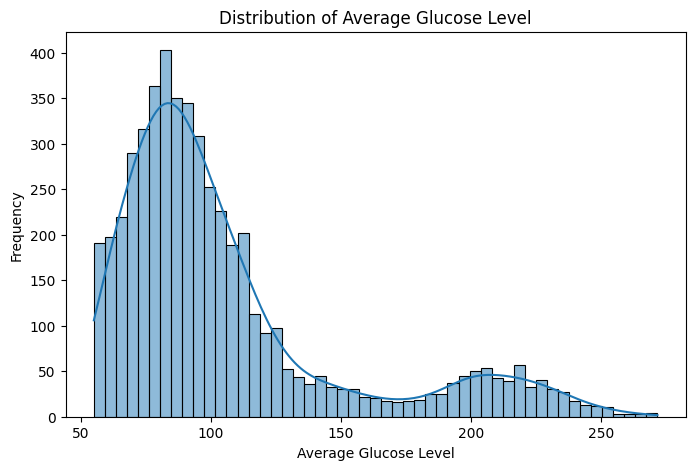

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(df["avg_glucose_level"], kde=True)

plt.title("Distribution of Average Glucose Level")
plt.xlabel("Average Glucose Level")
plt.ylabel("Frequency")

plt.show()

BMI

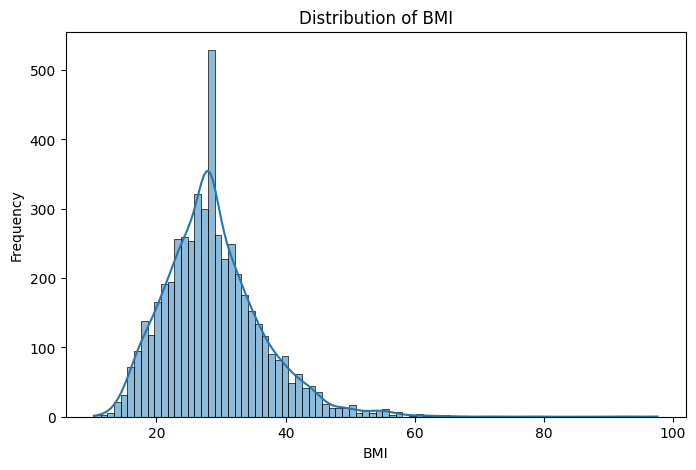

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(df["bmi"], kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

Skewness

In [58]:
distribution_analysis = pd.DataFrame({
    "Skewness": df[["age", "avg_glucose_level", "bmi"]].skew(),
    "Kurtosis": df[["age", "avg_glucose_level", "bmi"]].kurt()
})

distribution_analysis

,Skewness,Kurtosis
age,-0.137059,-0.991010
avg_glucose_level,1.572284,1.680479
bmi,1.088187,3.635306


Observation   :

 - Age is approximately balanced with slight skewness.

 - Average glucose level is positively skewed because some patients have considerably higher glucose levels.

- BMI is also positively skewed because of higher BMI observations.

 - Therefore, the numerical variables do not all follow a perfectly normal distribution.

Correlation

In [59]:
correlation_matrix = df[
    [
        "age",
        "hypertension",
        "heart_disease",
        "avg_glucose_level",
        "bmi",
        "stroke"
    ]
].corr()

correlation_matrix

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.000000,0.276398,0.263796,0.238171,0.324296,0.245257
hypertension,0.276398,1.000000,0.108306,0.174474,0.158293,0.127904
heart_disease,0.263796,0.108306,1.000000,0.161857,0.036916,0.134914
avg_glucose_level,0.238171,0.174474,0.161857,1.000000,0.166876,0.131945
bmi,0.324296,0.158293,0.036916,0.166876,1.000000,0.036110
stroke,0.245257,0.127904,0.134914,0.131945,0.036110,1.000000


Heatmap

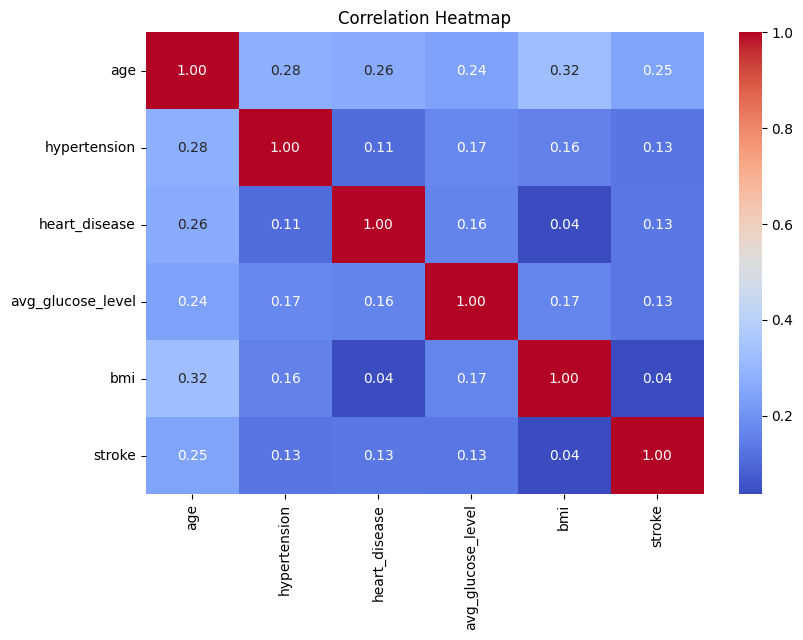

In [60]:
plt.figure(figsize=(9,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Correlation with Stroke

In [61]:
stroke_correlation = correlation_matrix["stroke"].sort_values(
    ascending=False
)

stroke_correlation

,stroke
stroke,1.000000
age,0.245257
heart_disease,0.134914
avg_glucose_level,0.131945
hypertension,0.127904
bmi,0.036110


Observation   :

 - Age has the strongest positive numerical relationship with stroke among the main numerical variables.

 - Heart disease, hypertension and average glucose level also have positive relationships with stroke.

 - BMI has a very weak positive relationship with stroke.

 - These correlations show relationships in the dataset and should not be interpreted as proof of causation.

Covariance

In [62]:
covariance_matrix = df[
    [
        "age",
        "hypertension",
        "heart_disease",
        "avg_glucose_level",
        "bmi",
        "stroke"
    ]
].cov()

covariance_matrix

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,511.331792,1.853816,1.348494,243.882731,56.462308,1.194146
hypertension,1.853816,0.087976,0.007262,2.343429,0.361501,0.008169
heart_disease,1.348494,0.007262,0.051104,1.656923,0.064255,0.006567
avg_glucose_level,243.882731,2.343429,1.656923,2050.600820,58.183489,1.286527
bmi,56.462308,0.361501,0.064255,58.183489,59.283260,0.059866
stroke,1.194146,0.008169,0.006567,1.286527,0.059866,0.046363


Observation  :     


 - Positive covariance means that two variables tend to increase together, while negative covariance indicates an opposite movement.

 - The covariance results help identify the direction of relationships between the numerical variables.

 - Because covariance depends on the scale of the variables, correlation is more suitable for comparing the strength of relationships.

# 2. Hypothesis Testing

T-Test — Age and Stroke

In [63]:
stroke_age = df[df["stroke"] == 1]["age"]

no_stroke_age = df[df["stroke"] == 0]["age"]

t_stat, p_value = ttest_ind(
    stroke_age,
    no_stroke_age,
    equal_var=False
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 29.68626563006023
P-Value: 2.115684848347272e-95


 Hypotheses  :      


 - H0 (Null Hypothesis):

 - - The mean age of stroke patients and non-stroke patients is the same.

 - H1 (Alternate Hypothesis):

 - - The mean age of stroke patients and non-stroke patients is different.

Decision

In [64]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


 Result Interpretation  :      


 - The p-value is expected to be less than 0.05.

 - Therefore, the null hypothesis is rejected.

 - There is statistically significant evidence that the average age differs between stroke and non-stroke patients.

 Business Interpretation  :      


 - Age shows a statistically significant difference between stroke and non-stroke patients.

 - Older patients are more represented among stroke cases, so age should be considered during further stroke-risk analysis.

Chi-Square Test — Hypertension and Stroke

In [65]:
contingency_table = pd.crosstab(
    df["hypertension"],
    df["stroke"]
)

contingency_table

stroke,0,1
hypertension,,
0,4429,183
1,432,66


In [66]:
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p_value)
print("Degrees of Freedom:", degrees_of_freedom)

Chi-Square Statistic: 81.6053682482931
P-Value: 1.661621901511823e-19
Degrees of Freedom: 1


 Hypotheses  :     


 - H0 (Null Hypothesis):

 - - There is no association between hypertension and stroke.

 - H1 (Alternate Hypothesis):

 - - There is an association between hypertension and stroke.

Decision

In [67]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


Interpretation  :      
 - The p-value is expected to be below 0.05.

 - Therefore, the null hypothesis is rejected.

 - There is statistically significant evidence of an association between hypertension and stroke in this dataset.

 Business Interpretation  :     


 - Patients with hypertension have a higher observed stroke rate.

 - Therefore, hypertension is an important health factor to consider when identifying patient groups that may need closer monitoring.

ANOVA — Age and Work Type

In [68]:
work_groups = []

for work in df["work_type"].unique():
    work_groups.append(
        df[df["work_type"] == work]["age"]
    )

f_stat, p_value = f_oneway(*work_groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: 1110.085063205303
P-Value: 0.0


 Hypotheses  :       


 - H0 (Null Hypothesis):

 - - The mean age is the same across all work-type groups.

 - H1 (Alternate Hypothesis):

 - - At least one work-type group has a different mean age.

Decision

In [69]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


 Interpretation  :    


 - The ANOVA test determines whether there is a statistically significant difference in average age between the different work-type groups.

 - If the p-value is below 0.05, the null hypothesis is rejected and at least one group has a different average age.

 Business Interpretation  :      


 - The result helps understand whether the age profile differs across work groups.

 - This does not mean that work type directly causes stroke.

# 3. Confidence Interval Analysis

3.1 Confidence Interval Function

In [70]:
def confidence_interval(data, confidence=0.95):

    mean = np.mean(data)

    standard_error = stats.sem(data)

    interval = stats.t.interval(
        confidence,
        df=len(data) - 1,
        loc=mean,
        scale=standard_error
    )

    return mean, interval[0], interval[1]

Age

In [71]:
age_mean, age_lower, age_upper = confidence_interval(
    df["age"]
)

print("Mean Age:", age_mean)
print("95% CI Lower:", age_lower)
print("95% CI Upper:", age_upper)

Mean Age: 43.226614481409
95% CI Lower: 42.606471349101504
95% CI Upper: 43.8467576137165


Interpretation  :     


 - The 95% confidence interval gives a plausible range for the population mean age represented by the sample.

 - Instead of reporting only the sample mean, the confidence interval also shows the uncertainty around the estimated population mean.

3.3 Average Glucose Level

In [72]:
glucose_mean, glucose_lower, glucose_upper = confidence_interval(
    df["avg_glucose_level"]
)

print("Mean Glucose:", glucose_mean)
print("95% CI Lower:", glucose_lower)
print("95% CI Upper:", glucose_upper)

Mean Glucose: 106.1476771037182
95% CI Lower: 104.90579289716432
95% CI Upper: 107.38956131027207


Interpretation  :    


 - The confidence interval gives a plausible range for the population mean glucose level represented by the dataset.

 - This provides more information than reporting only the sample mean.

BMI

In [73]:
bmi_mean, bmi_lower, bmi_upper = confidence_interval(
    df["bmi"]
)

print("Mean BMI:", bmi_mean)
print("95% CI Lower:", bmi_lower)
print("95% CI Upper:", bmi_upper)

Mean BMI: 28.862035225048924
95% CI Lower: 28.650877692176444
95% CI Upper: 29.073192757921404


Interpretation  :    


 - The 95% confidence interval provides a plausible range for the population mean BMI represented by the sample.

 - The interval reflects uncertainty when estimating the population value from the available patient records.

# 4. Feature Engineering

Age Group

In [74]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 40, 60, 100],
    labels=[
        "Young",
        "Adult",
        "Middle_Age",
        "Senior"
    ],
    right=False
)

In [75]:
df["age_group"].value_counts()

,count
age_group,
Middle_Age,1564
Senior,1376
Adult,1314
Young,856


Justification  :    


 - Age was an important variable in the previous analysis.

 - Creating Age Group makes it easier to compare stroke occurrence between different

BMI Category

In [76]:
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

In [77]:
df["bmi_category"].value_counts()

,count
bmi_category,
Obese,1893
Overweight,1610
Normal,1258
Underweight,349


Justification  :     


 - BMI is a continuous numerical variable.

 - Converting it into categories makes the results easier to understand and compare between different patient groups.

Combined Disease Indicator

In [78]:
df["combined_disease_indicator"] = (
    df["hypertension"] +
    df["heart_disease"]
)

In [79]:
df["disease_status"] = np.select(
    [
        df["combined_disease_indicator"] == 0,
        df["combined_disease_indicator"] == 1,
        df["combined_disease_indicator"] == 2
    ],
    [
        "No Disease",
        "One Condition",
        "Both Conditions"
    ],
    default="Unknown"
)

In [80]:
df["disease_status"].value_counts()

,count
disease_status,
No Disease,4400
One Condition,646
Both Conditions,64


ustification  :     


 - Hypertension and heart disease were both important health variables in the earlier analysis.

 - Combining them helps identify whether a patient has neither condition, one condition or both conditions.

Glucose Category

In [81]:
df["glucose_category"] = pd.cut(
    df["avg_glucose_level"],
    bins=[0, 70, 100, 126, np.inf],
    labels=[
        "Low",
        "Normal",
        "High",
        "Very_High"
    ]
)

In [82]:
df["glucose_category"].value_counts()

,count
glucose_category,
Normal,2375
High,998
Very_High,981
Low,756


Justification  :    


 - Average glucose level showed a relationship with stroke in the previous analysis.

 - Grouping glucose values makes it easier to compare stroke occurrence between different glucose ranges.

Health Score

In [83]:
df["health_score"] = (
    df["hypertension"] +
    df["heart_disease"]
)

In [84]:
df["health_score"].value_counts().sort_index()

,count
health_score,
0,4400
1,646
2,64


Justification  :     


 - The Health Score combines the hypertension and heart disease indicators into one simple measure.

 - It provides a quick summary of the presence of these two health conditions.

# 5. Feature Evaluation

Age Group Evaluation

In [85]:
age_group_analysis = df.groupby(
    "age_group",
    observed=False
).agg(
    Patients=("stroke", "count"),
    Stroke_Cases=("stroke", "sum"),
    Stroke_Rate=("stroke", "mean")
)

age_group_analysis["Stroke_Rate"] *= 100

age_group_analysis

,Patients,Stroke_Cases,Stroke_Rate
age_group,,,
Young,856,2,0.233645
Adult,1314,6,0.456621
Middle_Age,1564,60,3.836317
Senior,1376,181,13.154070


Observation  :     


 - The Age Group feature makes the relationship between age and stroke easier to compare.

 - Older age groups show a higher observed stroke rate than younger groups.

 - Therefore, Age Group improves the interpretation of the original age variable.

BMI Category Evaluation

In [86]:
bmi_analysis = df.groupby(
    "bmi_category",
    observed=False
).agg(
    Patients=("stroke", "count"),
    Stroke_Cases=("stroke", "sum"),
    Stroke_Rate=("stroke", "mean")
)

bmi_analysis["Stroke_Rate"] *= 100

bmi_analysis

,Patients,Stroke_Cases,Stroke_Rate
bmi_category,,,
Underweight,349,1,0.286533
Normal,1258,37,2.941176
Overweight,1610,115,7.142857
Obese,1893,96,5.071315


Observation  :    


 - BMI Category allows stroke rates to be compared between different BMI groups.

 - This provides a simpler group-level interpretation than looking at individual BMI

Disease Status Evaluation

In [87]:
disease_analysis = df.groupby(
    "disease_status"
).agg(
    Patients=("stroke", "count"),
    Stroke_Cases=("stroke", "sum"),
    Stroke_Rate=("stroke", "mean")
)

disease_analysis["Stroke_Rate"] *= 100

disease_analysis

,Patients,Stroke_Cases,Stroke_Rate
disease_status,,,
Both Conditions,64,13,20.312500
No Disease,4400,149,3.386364
One Condition,646,87,13.467492


Observation  :     


 - Disease Status combines hypertension and heart disease into one feature.

 - This makes it easier to compare patients with no condition, one condition and both conditions.

 - The feature therefore provides additional understanding of the combined health profile.

Glucose Category Evaluation

In [88]:
glucose_analysis = df.groupby(
    "glucose_category",
    observed=False
).agg(
    Patients=("stroke", "count"),
    Stroke_Cases=("stroke", "sum"),
    Stroke_Rate=("stroke", "mean")
)

glucose_analysis["Stroke_Rate"] *= 100

glucose_analysis

,Patients,Stroke_Cases,Stroke_Rate
glucose_category,,,
Low,756,27,3.571429
Normal,2375,85,3.578947
High,998,37,3.707415
Very_High,981,100,10.193680


Observation  :     


 - The Glucose Category feature makes it easier to compare stroke occurrence across different glucose ranges.

 - It converts a continuous measurement into understandable groups and therefore improves interpretation.

Visual Evaluation

Age Group

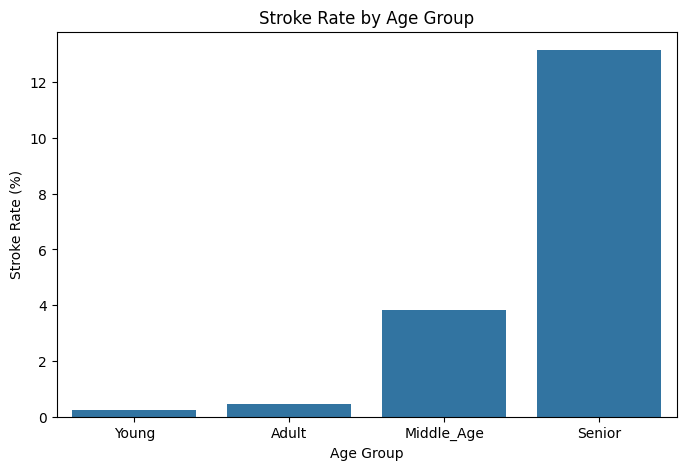

In [89]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=age_group_analysis.reset_index(),
    x="age_group",
    y="Stroke_Rate"
)

plt.title("Stroke Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Stroke Rate (%)")

plt.show()

Disease Status

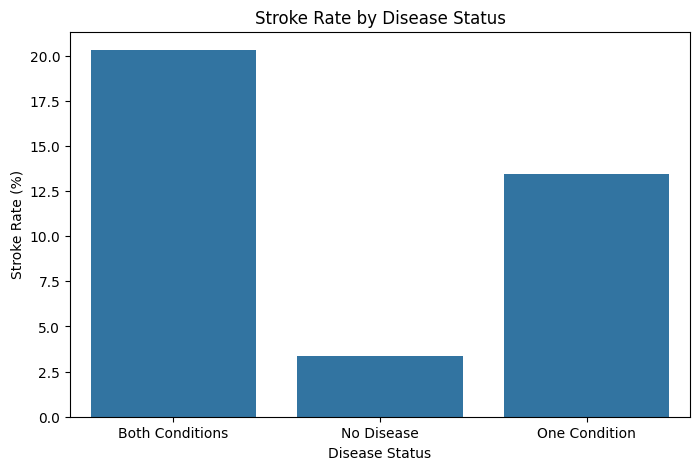

In [90]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=disease_analysis.reset_index(),
    x="disease_status",
    y="Stroke_Rate"
)

plt.title("Stroke Rate by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Stroke Rate (%)")

plt.show()

Overall Evaluation  :      

 - The engineered features improve data understanding by converting raw numerical health measurements into meaningful groups.

 - Age Group makes age-related patterns easier to communicate.

 - BMI Category provides an understandable classification of BMI.

 - Disease Status combines hypertension and heart disease into a single feature.

 - Glucose Category makes glucose-related patterns easier to compare.

 - The supporting group-level stroke rates show that these engineered features are useful for interpretation and business communication.

# 6. Final Business Recommendations

Final Business Recommendations  :    



1. Age should be considered an important factor during stroke-risk assessment because stroke cases are more common among older patients in this dataset.

2. Patients with hypertension should receive appropriate monitoring because the analysis shows a higher observed stroke rate among patients with hypertension.

3. Patients with heart disease should also receive closer attention because stroke occurrence is higher among this group.

4. Glucose levels should be monitored as part of general patient health assessment because higher glucose levels were observed among stroke patients.

5. Age Group, BMI Category, Glucose Category and Disease Status can make patient information easier to understand and compare.

6. Combining hypertension and heart disease into a single feature helps identify patients with multiple health conditions.

7. The statistical tests provide evidence of relationships in the dataset, but statistical association should not be interpreted as proof of direct causation.

8. The stroke dataset contains substantially fewer stroke cases than non-stroke cases. Future predictive modelling should therefore account for this class imbalance.

9. Healthcare professionals can use these findings as supporting information for preventive-care analysis, while actual medical decisions should be based on clinical assessment.

10. Further predictive modelling can be performed to investigate whether the identified variables and engineered features can help identify patients with higher likelihood of stroke.

In [91]:
df.to_csv(
    "stroke_data_sprint3_feature_engineered.csv",
    index=False
)

print("Sprint 3 dataset saved successfully.")

Sprint 3 dataset saved successfully.


In [92]:
print(df.shape)
print(df.columns.tolist())

(5110, 18)
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'age_group', 'bmi_category', 'combined_disease_indicator', 'disease_status', 'glucose_category', 'health_score']


# Sprint 3 Deliverables

1. Statistical Analysis Notebook  :    




 - Central tendency
 - Dispersion
 - Distribution analysis
 - Correlation
 - Covariance
 - Interpretation

2. Feature Engineering Notebook  :    





 - Age Group
 - BMI Category
 - Combined Disease Indicator
 - Glucose Category
 - Health Score
 - Justification for each

3. Hypothesis Testing Report  :    




 - T-Test
 - Chi-Square Test
 - ANOVA
 - Null hypothesis
 - Alternate hypothesis
 - Test statistic
 - p-value
 - Decision
 - Business interpretation

4. Feature Documentation  :     





 - Feature name
 - Creation method
 - Reason for creation
 - Business purpose
 - Evaluation

5. Final Business Recommendations  :    





 - Overall findings
 - Practical recommendations
 - High-risk patient discussion
 - Preventive-care recommendations

In [93]:
print("Final Sprint 3 Dataset Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Final Sprint 3 Dataset Shape: (5110, 18)
Columns:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'age_group', 'bmi_category', 'combined_disease_indicator', 'disease_status', 'glucose_category', 'health_score']


In [94]:
from google.colab import files

df.to_csv("stroke_data_sprint3_final.csv", index=False)

files.download("stroke_data_sprint3_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>